# Яндекс Афиша: исследовательский анализ данных о бронировании билетов

**Автор:** Каламагин Евгений Викторович  
**Период данных:** 1 июня – 31 октября 2024 года  
**Дашборд:** [Yandex DataLens](https://datalens.yandex/nozis2qzh2f06?_share_link=public&state=c50dcbe4123&tab=Z4)

---

## Цели и задачи проекта

**Контекст.** На дашборде, которым пользуются коллеги из продуктовой команды, видно, что с наступлением осени количество заказов растёт, а средняя стоимость заказа имеет тенденцию к снижению. Причины неясны: сработала сезонность и пользователи поменяли предпочтения, или изменилась аудитория?

**Цель:** с помощью исследовательского анализа данных (EDA) выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.

**Задачи:**
1. Загрузить данные и оценить их качество.
2. Провести предобработку: пропуски, категории, выбросы, дубликаты, типы данных, приведение выручки к рублям, новые признаки.
3. Изучить сезонные изменения по типам мероприятий, устройствам и возрастным рейтингам; динамику выручки с одного билета.
4. Изучить осеннюю активность пользователей (DAU, заказы на пользователя, средняя цена билета) и недельную цикличность.
5. Выделить ключевые регионы и билетных партнёров.
6. Проверить две статистические гипотезы об активности пользователей мобильных и стационарных устройств.
7. Сформулировать общий вывод и рекомендации.

## Описание данных

Используются три датасета.

**`final_tickets_orders_df.csv`** — заказы билетов с мобильных (`mobile`) и стационарных (`desktop`) устройств:

| Поле | Описание |
|---|---|
| `order_id` | уникальный идентификатор заказа |
| `user_id` | уникальный идентификатор пользователя |
| `created_dt_msk` | дата создания заказа (МСК) |
| `created_ts_msk` | дата и время создания заказа (МСК) |
| `event_id` | идентификатор мероприятия |
| `cinema_circuit` | сеть кинотеатров (`нет`, если не применимо) |
| `age_limit` | возрастное ограничение мероприятия |
| `currency_code` | валюта оплаты (`rub`, `kzt`) |
| `device_type_canonical` | тип устройства (`mobile`, `desktop`) |
| `revenue` | выручка от заказа |
| `service_name` | билетный оператор |
| `tickets_count` | количество билетов в заказе |
| `total` | общая сумма заказа |
| `days_since_prev` | дней с предыдущей покупки пользователя (пропуск — первая покупка) |

**`final_tickets_events_df.csv`** — мероприятия (фильмы исключены): `event_id`, `event_name`, `event_type_description`, `event_type_main`, `organizers`, `region_name`, `city_name`, `city_id`, `venue_id`, `venue_name`, `venue_address`.

**`final_tickets_tenge_df.csv`** — курс казахстанского тенге к рублю за 2024 год: `nominal` (100 тенге), `data` (дата), `curs` (курс: сколько рублей за `nominal` тенге), `cdx` (`kzt`).

## Структура проекта

0. Оформление тетради
1. Загрузка данных и знакомство с ними
2. Предобработка данных и подготовка к исследованию
3. Исследовательский анализ данных
   - 3.1. Распределение заказов по сегментам и сезонные изменения
   - 3.2. Осенняя активность пользователей
   - 3.3. Популярные события и партнёры
4. Статистический анализ данных
5. Общий вывод и рекомендации

### Подключение библиотек

`pandas` и `numpy` — работа с данными, `matplotlib` и `seaborn` — графики, `scipy.stats` — статистические тесты. Единый стиль графиков задаётся один раз в начале тетради.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

---
# Шаг 1. Загрузка данных и знакомство с ними

Три датасета загружаются функцией `load_csv`: она ищет файл рядом с тетрадью и в типичных папках платформы, поэтому тетрадь запускается и в Яндекс Практикуме, и локально. После загрузки выводится размер каждой таблицы.

In [2]:
def load_csv(name):
    """Ищет файл рядом с тетрадью и в типичных папках платформы."""
    for base in ['', '/datasets/', 'datasets/', 'data/']:
        try:
            return pd.read_csv(base + name)
        except FileNotFoundError:
            continue
    raise FileNotFoundError(f'Не найден файл {name}. Положите его рядом с тетрадью или поправьте путь.')


orders = load_csv('final_tickets_orders_df.csv')
events = load_csv('final_tickets_events_df.csv')
tenge = load_csv('final_tickets_tenge_df.csv')

for name, d in [('orders', orders), ('events', events), ('tenge', tenge)]:
    print(f'{name}: {d.shape[0]:,} строк, {d.shape[1]} столбцов')

orders: 290,849 строк, 14 столбцов
events: 22,427 строк, 11 столбцов
tenge: 357 строк, 4 столбцов


### 1.1. Датасет с заказами

Первые строки и типы столбцов таблицы заказов. Столбцы с датами загружены как строки (`object`), а пропуски есть только в `days_since_prev` — у первых покупок пользователей.

In [3]:
display(orders.head())
orders.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,"1,521.94",Край билетов,4,"10,870.99",NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,"2,067.51",NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,"1,258.57",За билетом!,4,"13,984.16",75.00
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,"1,390.41",Билеты без проблем,3,"10,695.43",83.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

### 1.2. Датасет с мероприятиями

В таблице мероприятий 22 427 строк, пропусков нет. Названия мероприятий, организаторы, регионы и площадки анонимизированы, поэтому значения выглядят необычно.

In [4]:
display(events.head())
events.info()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


### 1.3. Датасет с курсом тенге

Курс тенге дан на 357 дат за 2024 год: значение `curs` — это стоимость 100 тенге в рублях. Курс есть не на каждую календарную дату, это учтётся при конвертации.

In [5]:
display(tenge.head())
tenge.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.94,kzt
1,2024-01-11,100,19.73,kzt
2,2024-01-12,100,19.58,kzt
3,2024-01-13,100,19.45,kzt
4,2024-01-14,100,19.45,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


### 1.4. Первичные проверки

Проверяются период заказов, уникальность `order_id`, число пользователей и мероприятий, а также связность таблиц. 238 заказов ссылаются на `event_id`, которого нет в таблице мероприятий.

In [6]:
print('Период заказов:', orders['created_dt_msk'].min(), '—', orders['created_dt_msk'].max())
print('Уникальных заказов:', orders['order_id'].nunique(), 'из', len(orders))
print('Уникальных пользователей:', orders['user_id'].nunique())
print('Уникальных мероприятий в заказах:', orders['event_id'].nunique())
print('Мероприятий в events:', events['event_id'].nunique(), 'из', len(events), 'строк')
print('Заказов с event_id, которых нет в events (предположительно фильмы):',
      (~orders['event_id'].isin(events['event_id'])).sum())
print('Период курса тенге:', tenge['data'].min(), '—', tenge['data'].max())
print('Значения nominal:', tenge['nominal'].unique(), '| cdx:', tenge['cdx'].unique())

Период заказов: 2024-06-01 — 2024-10-31
Уникальных заказов: 290849 из 290849
Уникальных пользователей: 21940
Уникальных мероприятий в заказах: 22446
Мероприятий в events: 22427 из 22427 строк
Заказов с event_id, которых нет в events (предположительно фильмы): 238
Период курса тенге: 2024-01-10 — 2024-12-31
Значения nominal: [100] | cdx: ['kzt']


Общая статистика по таблице заказов: число уникальных значений, самые частые категории, разброс числовых столбцов.

In [7]:
display(orders.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,"290,849.00",NaN,NaN,NaN,"4,326,811.57","2,497,577.52",1.00,"2,164,039.00","4,327,816.00","6,488,606.00","8,653,108.00"
user_id,290849,21940,0beb8fc0c0a9ce1,10258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_dt_msk,290849,153,2024-10-01,7313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_ts_msk,290849,280986,2024-10-01 11:20:05,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_id,"290,849.00",NaN,NaN,NaN,"438,079.13","147,396.39","4,436.00","361,961.00","498,329.00","546,284.00","592,325.00"
cinema_circuit,290849,6,нет,289451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_limit,"290,849.00",NaN,NaN,NaN,10.21,6.52,0.00,6.00,12.00,16.00,18.00
currency_code,290849,2,rub,285780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type_canonical,290849,2,mobile,232679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenue,"290,849.00",NaN,NaN,NaN,625.08,"1,227.32",-90.76,116.79,355.34,809.75,"81,174.54"


### Промежуточный вывод по шагу 1

На первом этапе проверили структуру, объём и согласованность исходных данных. В orders содержится 290 849 строк и 14 столбцов, в events — 22 427 строк и 11 столбцов, в tenge — 357 строк и 4 столбца. Период заказов соответствует заявленному: 1 июня — 31 октября 2024 года.

Даты и время (created_dt_msk, created_ts_msk, data) загружены как строки и требуют преобразования в datetime. В orders обнаружены пропуски только в days_since_prev — они соответствуют первой покупке пользователя и являются ожидаемыми.

При проверке связности таблиц 238 заказов (0,08%) не имеют соответствующей записи в events. Это согласуется с описанием данных: из выгрузки мероприятий исключены фильмы, поэтому такие заказы не используются в дальнейшем анализе.

---
# Шаг 2. Предобработка данных и подготовка их к исследованию

### 2.1. Объединение данных

Объединяем заказы с мероприятиями по `event_id` (левое соединение, чтобы ничего не потерять на этапе проверки). Заранее убеждаемся, что `event_id` в `events` уникален — иначе соединение размножит строки заказов.

In [8]:
n_start = len(orders)  # запомним исходный объём для итоговой сводки

print('Дубликатов event_id в events:', events['event_id'].duplicated().sum())
events_u = events.drop_duplicates('event_id')

df = orders.merge(events_u, on='event_id', how='left')
print('Строк до объединения:', len(orders), '| после:', len(df))
df.head()

Дубликатов event_id в events: 0
Строк до объединения: 290849 | после: 290849


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,"1,521.94",Край билетов,4,"10,870.99",NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.00,"3,972.00","Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,"2,067.51",NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.00,"2,941.00","Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,"1,258.57",За билетом!,4,"13,984.16",75.00,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.00,"4,507.00","Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.00,"3,574.00","Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,"1,390.41",Билеты без проблем,3,"10,695.43",83.00,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.00,"1,896.00","Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


### 2.2. Пропуски

Функция `missing_report` показывает столбцы с пропусками и их долю. После объединения таблиц пропуски появились во всех столбцах из `events` (238 строк) — это заказы без информации о мероприятии; в `days_since_prev` пропуски ожидаемые.

In [9]:
def missing_report(d):
    rep = pd.DataFrame({'пропусков': d.isna().sum(), 'доля, %': d.isna().mean() * 100})
    return rep[rep['пропусков'] > 0]


missing_report(df)

,пропусков,"доля, %"
days_since_prev,21940,7.54
event_name,238,0.08
event_type_description,238,0.08
event_type_main,238,0.08
organizers,238,0.08
region_name,238,0.08
city_name,238,0.08
city_id,238,0.08
venue_id,238,0.08
venue_name,238,0.08


Пропуски во всех столбцах из `events` — это заказы, для которых в выгрузке мероприятий нет информации. По условию проекта из событий исключены фильмы, поэтому такие заказы — это заказы на фильмы. Анализ строится по остальным типам мероприятий, поэтому такие строки удаляем и фиксируем, сколько данных ушло.

In [10]:
no_event = df['event_name'].isna()
print(f'Заказов без информации о мероприятии: {no_event.sum():,} ({no_event.mean():.2%})')

df = df[~no_event].copy()
print('Осталось строк:', len(df))

# Кроме days_since_prev, пропусков быть не должно
missing_report(df)

Заказов без информации о мероприятии: 238 (0.08%)
Осталось строк: 290611


,пропусков,"доля, %"
days_since_prev,21913,7.54


### 2.3. Категориальные значения

Из текстовых столбцов убираются лишние пробелы, а технические категории (`device_type_canonical`, `currency_code`, `event_type_main`) приводятся к нижнему регистру. Затем выводится распределение значений по основным категориям: устройства, валюты, возрастные ограничения, типы мероприятий, сети кинотеатров. Опечаток и дублей категорий не видно: устройств два, валют две.

In [11]:
# Уберём случайные пробелы по краям в текстовых столбцах и приведём технические категории к нижнему регистру
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = df[col].str.strip()

for col in ['device_type_canonical', 'currency_code', 'event_type_main']:
    df[col] = df[col].str.lower()

for col in ['device_type_canonical', 'currency_code', 'age_limit', 'event_type_main', 'cinema_circuit']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).to_string())
    print()

--- device_type_canonical ---
mobile     232490
desktop     58121

--- currency_code ---
rub    285542
kzt      5069

--- age_limit ---
16    78556
12    62474
0     61487
6     52161
18    35933

--- event_type_main ---
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989

--- cinema_circuit ---
нет           289213
Другое          1261
КиноСити         122
Москино            7
Киномакс           7
ЦентрФильм         1



Справочные признаки — билетные операторы, регионы, города, площадки — проверяются на объём и корректность написания.

In [12]:
print('Билетных операторов:', df['service_name'].nunique())
print(df['service_name'].value_counts().to_string())
print()
print('Регионов:', df['region_name'].nunique(), '| городов:', df['city_name'].nunique(),
      '| площадок:', df['venue_id'].nunique(), '| типов (description):', df['event_type_description'].nunique())
print()
print(sorted(df['region_name'].unique()))

Билетных операторов: 36
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет      

Проверка на значения, которые могут обозначать пропуск (`нет`, `неизвестно`, `n/a` и т. п.). Заглушки есть только в `cinema_circuit`, где `нет` — штатная отметка «не применимо», поэтому значение сохраняется как есть.

In [13]:
# Значения, которые могут обозначать пропуск или отсутствие информации
placeholders = ['', 'нет', 'неизвестно', 'не указано', 'не определено', 'unknown', 'n/a', 'na', 'none', 'null', '-', '—', '?']

for col in df.select_dtypes(include='object').columns:
    mask = df[col].astype(str).str.strip().str.lower().isin(placeholders)
    if mask.any():
        print(f'{col}: {mask.sum():,} значений-заглушек ->', df.loc[mask, col].unique()[:5])

cinema_circuit: 289,213 значений-заглушек -> ['нет']


### 2.4. Количественные значения: распределение и выбросы

Статистики `revenue` и `tickets_count` считаются отдельно по валютам: масштабы несопоставимы (медиана выручки — 347 руб. и 3 699 тенге). Найдены 381 заказ с отрицательной выручкой (минимум −90,76 руб.) и 5 526 заказов с нулевой; максимум билетов в заказе — 57 (в рублях).

In [14]:
display(df.groupby('currency_code')[['revenue', 'tickets_count']].describe().T)

print('revenue < 0 :', (df['revenue'] < 0).sum())
print('revenue == 0:', (df['revenue'] == 0).sum())
print('tickets_count <= 0:', (df['tickets_count'] <= 0).sum())

currency_code             kzt        rub
revenue       count  5,069.00 285,542.00
              mean   4,995.21     548.01
              std    4,916.75     871.75
              min        0.00     -90.76
              25%      518.10     114.17
              50%    3,698.83     346.63
              75%    7,397.66     793.32
              max   26,425.86  81,174.54
tickets_count count  5,069.00 285,542.00
              mean       2.76       2.75
              std        1.12       1.17
              min        1.00       1.00
              25%        2.00       2.00
              50%        3.00       3.00
              75%        4.00       4.00
              max        6.00      57.00

revenue < 0 : 381
revenue == 0: 5526
tickets_count <= 0: 0


Гистограммы и диаграммы размаха выручки и числа билетов по каждой валюте, а также квантили выручки. У рублёвых заказов очень длинный правый хвост: 99-й процентиль — 2 571 руб., а максимум — более 81 тыс. руб.

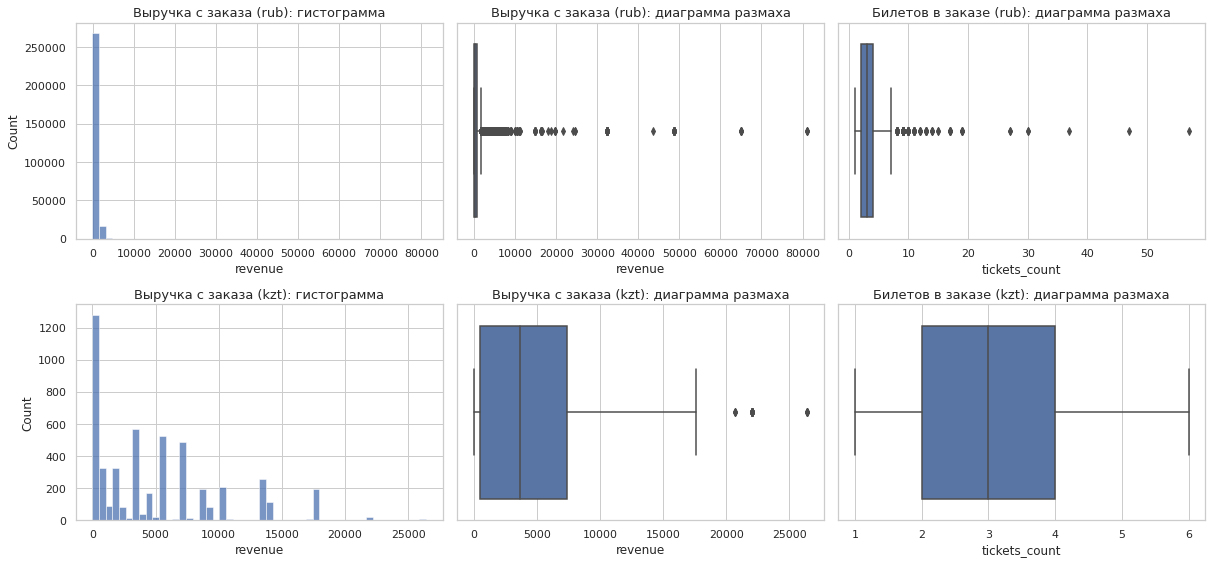

,0.50,0.90,0.95,0.99,1.00,1.00
currency_code,,,,,,
kzt,"3,698.83","13,212.93","13,784.26","17,617.24","22,021.55","26,425.86"
rub,346.63,"1,276.15","1,607.10","2,570.80","5,140.78","81,174.54"


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for i, cur in enumerate(['rub', 'kzt']):
    sub = df[df['currency_code'] == cur]
    sns.histplot(sub['revenue'], bins=50, ax=axes[i, 0])
    axes[i, 0].set_title(f'Выручка с заказа ({cur}): гистограмма')
    sns.boxplot(x=sub['revenue'], ax=axes[i, 1])
    axes[i, 1].set_title(f'Выручка с заказа ({cur}): диаграмма размаха')
    sns.boxplot(x=sub['tickets_count'], ax=axes[i, 2])
    axes[i, 2].set_title(f'Билетов в заказе ({cur}): диаграмма размаха')
plt.tight_layout()
plt.show()

display(df.groupby('currency_code')['revenue'].quantile([.5, .9, .95, .99, .999, 1]).unstack())

Отрицательная выручка не имеет смысла для проданных билетов (это возвраты или ошибки выгрузки), поэтому такие заказы удаляем. Нулевую выручку оставляем, но помним о ней при расчёте средних значений. Выбросы по 99-му процентилю отберём отдельно по валютам после проверки дубликатов.

In [16]:
n_before = len(df)
df = df[(df['revenue'] >= 0) & (df['tickets_count'] > 0)].copy()
print(f'Удалено заказов с отрицательной выручкой или нулём билетов: {n_before - len(df):,}')

Удалено заказов с отрицательной выручкой или нулём билетов: 381


### 2.5. Дубликаты

Сначала проверяем явные дубликаты и повтор `order_id`, затем — неявные: заказы, у которых совпадают все поля, кроме идентификатора заказа (и служебного `days_since_prev`). Один и тот же пользователь не должен купить те же билеты на то же мероприятие с тем же временем создания заказа дважды — это, скорее всего, техническая задвоенность.

In [17]:
print('Явных дубликатов (полное совпадение строк):', df.duplicated().sum())
print('Повторов order_id:', df['order_id'].duplicated().sum())

dup_cols = [c for c in orders.columns if c not in ('order_id', 'days_since_prev')]
dup_mask = df.duplicated(subset=dup_cols, keep='first')
print('Неявных дубликатов (без учёта order_id):', dup_mask.sum(), f'({dup_mask.mean():.3%})')

display(df[df.duplicated(subset=dup_cols, keep=False)].sort_values(dup_cols).head(10))

Явных дубликатов (полное совпадение строк): 0
Повторов order_id: 0
Неявных дубликатов (без учёта order_id): 40 (0.014%)


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.00,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.00,"4,443.00","Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.00,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.00,"4,443.00","Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,"1,556.05",Лови билет!,3,"19,450.63",11.00,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.00,"2,704.00","Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,"1,556.05",Лови билет!,3,"19,450.63",0.00,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.00,"2,704.00","Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,"6,016.94",32.00,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.00,"4,363.00","Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
53717,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,"6,016.94",0.00,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.00,"4,363.00","Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.00,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,"11,036.00","1,656.00","Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.00,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,"11,036.00","1,656.00","Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
68214,3326185,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,Билеты без проблем,2,"1,008.14",7.00,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43.00,"3,873.00","Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"
68215,3326272,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,Билеты без проблем,2,"1,008.14",0.00,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43.00,"3,873.00","Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"


In [18]:
# Доля дубликатов мала, повторяются все содержательные поля (включая время заказа с точностью до секунды) —
# оставляем по одной записи.
df = df[~dup_mask].copy()
print('Осталось строк:', len(df))

Осталось строк: 290190


### 2.6. Отбор выбросов по 99-му процентилю выручки

Выручка представлена в двух валютах с разным масштабом, поэтому 99-й процентиль считаем **отдельно для рублей и тенге**.

In [19]:
p99 = df.groupby('currency_code')['revenue'].quantile(0.99)
print('99-й процентиль выручки по валютам:')
print(p99)

n_before = len(df)
df = df[df['revenue'] <= df['currency_code'].map(p99)].copy()
print(f'\nУдалено выбросов: {n_before - len(df):,} ({(n_before - len(df)) / n_before:.2%})')
print(df.groupby('currency_code')['revenue'].describe())

99-й процентиль выручки по валютам:
currency_code
kzt   17,617.24
rub    2,570.80
Name: revenue, dtype: float64

Удалено выбросов: 2,828 (0.97%)
                   count     mean      std  min    25%      50%      75%  \
currency_code                                                              
kzt             5,039.00 4,894.27 4,742.96 0.00 512.60 3,698.83 7,397.66   
rub           282,323.00   511.52   500.91 0.00 113.05   341.73   782.44   

                    max  
currency_code            
kzt           17,617.24  
rub            2,570.80  


### 2.7. Преобразование типов данных

Даты приводятся к формату `datetime`, а `tickets_count` и `age_limit` — к `int8`, `days_since_prev` — к `float32`. Денежные столбцы остаются `float64`, чтобы не копить ошибки округления. Использование памяти уменьшилось с 475,1 до 435,4 МБ.

In [20]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2

df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

# Снижаем разрядность целочисленных и «дневных» столбцов.
# Денежные столбцы оставляем float64, чтобы не копить ошибки округления в суммах.
for col in ['tickets_count', 'age_limit']:
    df[col] = pd.to_numeric(df[col], downcast='integer')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f'Память: {mem_before:.1f} МБ -> {mem_after:.1f} МБ')
df[['created_dt_msk', 'created_ts_msk', 'tickets_count', 'age_limit', 'days_since_prev']].dtypes

Память: 475.1 МБ -> 435.4 МБ


created_dt_msk     datetime64[ns]
created_ts_msk     datetime64[ns]
tickets_count                int8
age_limit                    int8
days_since_prev           float32
dtype: object

### 2.8. Новые столбцы

- `revenue_rub` — выручка с заказа в рублях. Для тенге: `revenue * curs / nominal` (курс дан за 100 тенге) на дату заказа.
- `one_ticket_revenue_rub` — выручка с одного билета: `revenue_rub / tickets_count`.
- `month` — месяц оформления заказа.
- `season` — сезон: лето (июн–авг), осень (сен–ноя), зима (дек–фев), весна (мар–май).

Курс тенге есть не на каждую дату (выходные и праздники), поэтому пропуски заполняются последним известным курсом. Выручка в тенге переводится в рубли на дату заказа, после чего считаются `one_ticket_revenue_rub`, `month` и `season`. В проверочной выборке видно, что рублёвые заказы остаются без изменений.

In [21]:
tenge['data'] = pd.to_datetime(tenge['data'])

# Курс есть не на каждую календарную дату (выходные и праздники) — заполняем пропуски последним известным курсом
idx = pd.date_range(min(tenge['data'].min(), df['created_dt_msk'].min()),
                    max(tenge['data'].max(), df['created_dt_msk'].max()))
rates = tenge.drop_duplicates('data').set_index('data')['curs'].reindex(idx).ffill().bfill()
nominal = tenge['nominal'].iloc[0]

df['kzt_rate'] = df['created_dt_msk'].map(rates)
df['revenue_rub'] = np.where(df['currency_code'] == 'kzt',
                             df['revenue'] * df['kzt_rate'] / nominal,
                             df['revenue'])
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

df['month'] = df['created_dt_msk'].dt.month
season_map = {12: 'зима', 1: 'зима', 2: 'зима',
              3: 'весна', 4: 'весна', 5: 'весна',
              6: 'лето', 7: 'лето', 8: 'лето',
              9: 'осень', 10: 'осень', 11: 'осень'}
df['season'] = df['month'].map(season_map)

df = df.drop(columns='kzt_rate').reset_index(drop=True)

display(df[['currency_code', 'revenue', 'revenue_rub', 'tickets_count', 'one_ticket_revenue_rub', 'month', 'season']].sample(8, random_state=1))
print('Пропусков в новых столбцах:', df[['revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].isna().sum().sum())
print(df['season'].value_counts())

,currency_code,revenue,revenue_rub,tickets_count,one_ticket_revenue_rub,month,season
4082,rub,579.29,579.29,2,289.64,8,лето
94070,rub,15.78,15.78,2,7.89,8,лето
143284,rub,924.14,924.14,3,308.05,6,лето
269711,rub,314.47,314.47,1,314.47,10,осень
187299,rub,271.33,271.33,4,67.83,8,лето
187983,rub,219.15,219.15,3,73.05,8,лето
195143,rub,"1,087.78","1,087.78",3,362.59,10,осень
38316,rub,0.00,0.00,4,0.00,8,лето


Пропусков в новых столбцах: 0
осень    168418
лето     118944
Name: season, dtype: int64


### 2.9. Итог предобработки

Контрольная сводка после предобработки: сколько заказов, пользователей и мероприятий осталось, какой период охвачен и остались ли пропуски.

In [22]:
print(f'Исходно заказов: {n_start:,}')
print(f'После предобработки: {len(df):,} ({len(df) / n_start:.1%} от исходного объёма)')
print(f'Пользователей: {df["user_id"].nunique():,} | мероприятий: {df["event_id"].nunique():,}')
print(f'Период: {df["created_dt_msk"].min().date()} — {df["created_dt_msk"].max().date()}')
missing_report(df)

Исходно заказов: 290,849
После предобработки: 287,362 (98.8% от исходного объёма)
Пользователей: 21,827 | мероприятий: 22,293
Период: 2024-06-01 — 2024-10-31


,пропусков,"доля, %"
days_since_prev,21676,7.54


### Промежуточный вывод по шагу 2

Предобработка позволила сохранить 287 362 заказа, или 98,8% исходного объёма. Все таблицы успешно объединены по event_id, при этом заказы без информации о мероприятии (предположительно фильмы) были исключены: 238 заказов, или 0,08% исходных данных.

После обработки пропуски остались только в days_since_prev (21 676 значений, 7,54%), что связано с первыми покупками пользователей. Категориальные значения очищены от лишних пробелов и приведены к единому регистру; значение нет в cinema_circuit сохранено как штатная отметка «не применимо».

Удалены 381 заказ с отрицательной выручкой. Явных дубликатов и повторов order_id не обнаружено, однако найдено 40 неявных дубликатов (0,014%) — они удалены, поскольку содержательные поля полностью совпадали.

Для контроля экстремальных значений 99-й процентиль выручки рассчитан отдельно по валютам: 17 617,24 KZT и 2 570,80 RUB. По этому правилу удалено 2 828 заказов (0,97%).

---
# Шаг 3. Исследовательский анализ данных

## 3.1. Распределение заказов по сегментам и сезонные изменения

Данные охватывают период с июня по октябрь, поэтому **лето** — это июнь–август, **осень** — сентябрь–октябрь. Полного осеннего сезона в данных нет (октябрь — последний месяц), учтём это в выводах.

### 3.1.1. Заказы по месяцам

Число заказов и уникальных пользователей по месяцам и рост числа заказов к предыдущему месяцу.

,orders,users,orders_change_%
month,,,
июнь,34056,6200,NaN
июль,40359,6535,18.51
август,44529,7304,10.33
сентябрь,69262,9344,55.54
октябрь,99156,11441,43.16


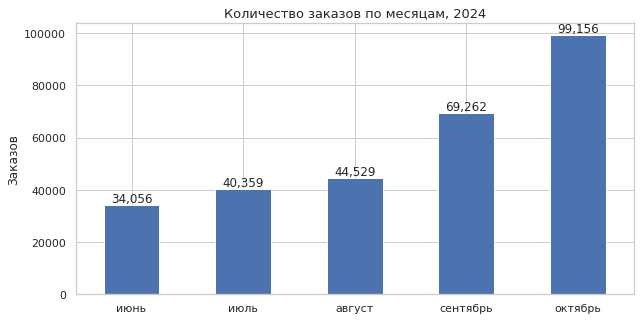

In [23]:
month_names = {6: 'июнь', 7: 'июль', 8: 'август', 9: 'сентябрь', 10: 'октябрь'}

monthly = (df.groupby('month')
             .agg(orders=('order_id', 'nunique'), users=('user_id', 'nunique'))
             .sort_index())
monthly['orders_change_%'] = monthly['orders'].pct_change() * 100
monthly.index = monthly.index.map(lambda m: month_names.get(m, str(m)))
display(monthly)

ax = monthly['orders'].plot(kind='bar', rot=0, color=sns.color_palette()[0])
for i, v in enumerate(monthly['orders']):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
ax.set_title('Количество заказов по месяцам, 2024')
ax.set_xlabel('')
ax.set_ylabel('Заказов')
plt.show()

### 3.1.2. Сравнение долей заказов летом и осенью

Абсолютное число заказов осенью больше, поэтому сравниваем **доли** внутри каждого сезона: для каждого сегмента — какая часть заказов сезона на него приходится.

=== Тип мероприятия ===


season,лето,осень,diff_pp
event_type_main,,,
концерты,42.68,37.25,-5.43
другое,27.08,19.64,-7.44
театр,20.13,25.37,5.24
стендап,5.34,4.11,-1.22
спорт,2.52,11.20,8.67
выставки,2.02,1.43,-0.60
ёлки,0.23,1.00,0.77


=== Тип устройства ===


season,лето,осень,diff_pp
device_type_canonical,,,
mobile,80.62,79.64,-0.98
desktop,19.38,20.36,0.98


=== Возрастной рейтинг (age_limit) ===


season,лето,осень,diff_pp
age_limit,,,
0,17.88,23.58,5.69
6,18.21,17.62,-0.59
12,20.54,22.12,1.58
16,28.38,26.25,-2.13
18,14.98,10.43,-4.55


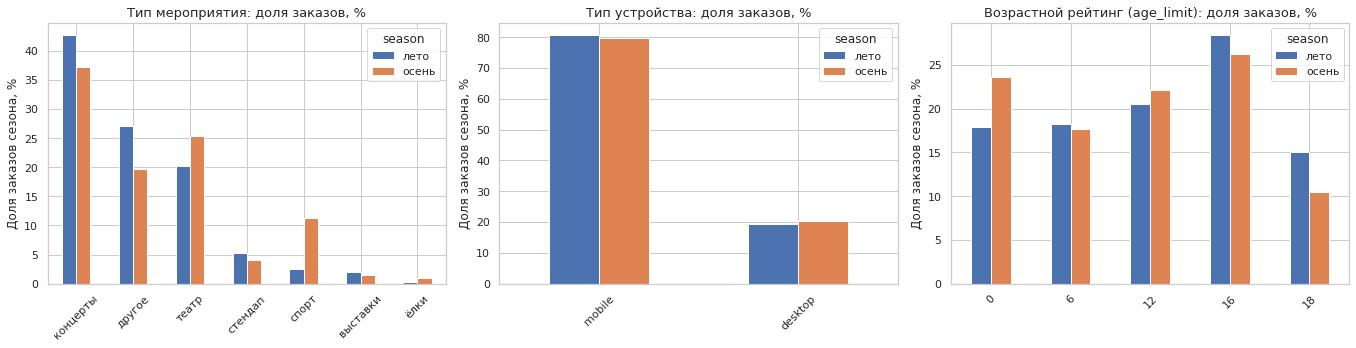

In [24]:
segments = {'event_type_main': 'Тип мероприятия',
            'device_type_canonical': 'Тип устройства',
            'age_limit': 'Возрастной рейтинг (age_limit)'}


def season_shares(data, col):
    cnt = data.groupby([col, 'season'])['order_id'].nunique().unstack('season').fillna(0)
    shr = cnt.div(cnt.sum(axis=0), axis=1) * 100
    shr = shr[['лето', 'осень']]
    shr['diff_pp'] = shr['осень'] - shr['лето']  # разница в процентных пунктах
    return shr


fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (col, title) in zip(axes, segments.items()):
    shr = season_shares(df, col)
    shr = shr.sort_index() if col == 'age_limit' else shr.sort_values('лето', ascending=False)
    print(f'=== {title} ===')
    display(shr.round(2))
    shr[['лето', 'осень']].plot(kind='bar', ax=ax, rot=45)
    ax.set_title(f'{title}: доля заказов, %')
    ax.set_xlabel('')
    ax.set_ylabel('Доля заказов сезона, %')
plt.tight_layout()
plt.show()

### 3.1.3. Выручка с одного билета: лето и осень

Для каждого типа мероприятия считаем среднюю выручку с одного билета (в рублях) и относительное изменение осени к лету.

season,лето,осень,change_%
event_type_main,,,
театр,214.14,175.98,-17.82
ёлки,271.44,229.59,-15.42
концерты,304.79,268.36,-11.95
другое,77.83,76.48,-1.74
спорт,50.81,50.02,-1.56
стендап,218.52,231.12,5.77
выставки,86.74,91.91,5.95


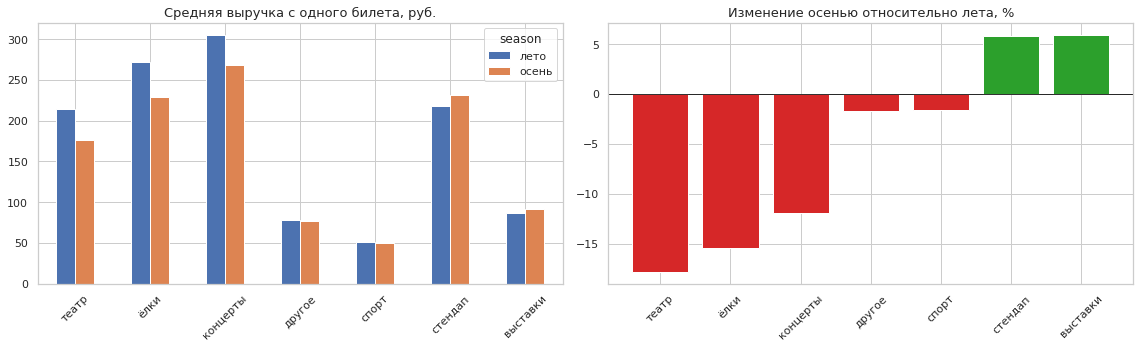

In [25]:
price = (df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub']
           .mean().unstack('season')[['лето', 'осень']])
price['change_%'] = (price['осень'] / price['лето'] - 1) * 100
price = price.sort_values('change_%')
display(price.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
price[['лето', 'осень']].plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Средняя выручка с одного билета, руб.')
axes[0].set_xlabel('')

colors = ['tab:red' if v < 0 else 'tab:green' for v in price['change_%']]
axes[1].bar(price.index, price['change_%'], color=colors)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Изменение осенью относительно лета, %')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Дополнительно: почему средняя цена билета могла снизиться?** Общее изменение средней цены можно разложить на две части:
- **эффект цены** — внутри типов мероприятий билеты подешевели/подорожали;
- **эффект структуры** — изменилась доля дешёвых и дорогих типов мероприятий в заказах.

In [26]:
w = df.groupby(['season', 'event_type_main'])['order_id'].nunique().unstack('season')
w = w.div(w.sum())[['лето', 'осень']]           # доли заказов по типам
p = price[['лето', 'осень']].reindex(w.index)   # средние цены по типам

overall = df.groupby('season')['one_ticket_revenue_rub'].mean()
total_change = overall['осень'] - overall['лето']
price_effect = (w['лето'] * (p['осень'] - p['лето'])).sum()
mix_effect = ((w['осень'] - w['лето']) * p['осень']).sum()

print(f'Средняя выручка с билета: лето {overall["лето"]:.1f} руб., осень {overall["осень"]:.1f} руб. '
      f'(изменение {total_change:+.1f} руб., {total_change / overall["лето"]:+.1%})')
print(f'  эффект цены внутри типов:      {price_effect:+.1f} руб.')
print(f'  эффект структуры (смена долей): {mix_effect:+.1f} руб.')
print(f'  сумма эффектов:                 {price_effect + mix_effect:+.1f} руб.')

Средняя выручка с билета: лето 209.6 руб., осень 178.4 руб. (изменение -31.2 руб., -14.9%)
  эффект цены внутри типов:      -22.9 руб.
  эффект структуры (смена долей): -8.3 руб.
  сумма эффектов:                 -31.2 руб.


### Промежуточный вывод по разделу 3.1

С июня по октябрь наблюдается выраженный рост числа заказов: с 34 056 в июне до 99 156 в октябре. Особенно заметный прирост пришёлся на сентябрь (+55,5% к августу) и октябрь (+43,2% к сентябрю). Число пользователей также растёт — с 6 200 в июне до 11 441 в октябре.

Осенью изменилась структура спроса. Доля театра выросла на 5,24 п.п., а спорта — на 8,67 п.п.; одновременно снизилась доля концертов на 5,43 п.п. и категории «другое» на 7,44 п.п. Доля мобильных заказов почти не изменилась: 80,62% летом против 79,64% осенью, то есть структура по устройствам в целом стабильна.

По возрастным рейтингам заметнее всего выросла доля мероприятий с рейтингом 0+ (+5,69 п.п.) и 12+ (+1,58 п.п.), а доля 18+ снизилась на 4,55 п.п. и 16+ — на 2,13 п.п.

Средняя выручка с одного билета снизилась с 209,6 до 178,4 руб., то есть на 31,2 руб. или 14,9%. Снижение наблюдается у театра (−17,82%), ёлок (−15,42%) и концертов (−11,95%); одновременно немного выросла средняя цена билета в стендапе (+5,77%) и на выставках (+5,95%).

Разложение изменения показывает, что основная часть снижения связана с изменением цены внутри типов мероприятий: −22,9 руб., тогда как изменение структуры спроса дало ещё −8,3 руб. Таким образом, снижение средней цены объясняется прежде всего удешевлением билетов внутри отдельных категорий, а не только переходом пользователей к другим типам мероприятий.

## 3.2. Осенняя активность пользователей

Далее используем **только осенние данные** (сентябрь–октябрь 2024).

In [27]:
autumn = df[df['season'] == 'осень'].copy()
print(f'Осенних заказов: {len(autumn):,}, период: {autumn["created_dt_msk"].min().date()} — {autumn["created_dt_msk"].max().date()}')

daily = (autumn.groupby('created_dt_msk')
               .agg(orders=('order_id', 'nunique'),
                    dau=('user_id', 'nunique'),
                    avg_ticket_price=('one_ticket_revenue_rub', 'mean'))
               .reset_index())
daily['orders_per_user'] = daily['orders'] / daily['dau']
display(daily.head())

Осенних заказов: 168,418, период: 2024-09-01 — 2024-10-31


,created_dt_msk,orders,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,200.17,2.35
1,2024-09-02,1376,573,190.02,2.40
2,2024-09-03,5094,777,80.65,6.56
3,2024-09-04,1760,684,179.36,2.57
4,2024-09-05,1941,738,189.80,2.63


Строятся графики четырёх ежедневных метрик осени с 7-дневным скользящим средним. На них виден аномальный день — 3 сентября: 5 094 заказа при DAU 777 и средней цене билета 80,65 руб. Такие всплески могут завышать средние по дням недели (3 сентября — вторник).

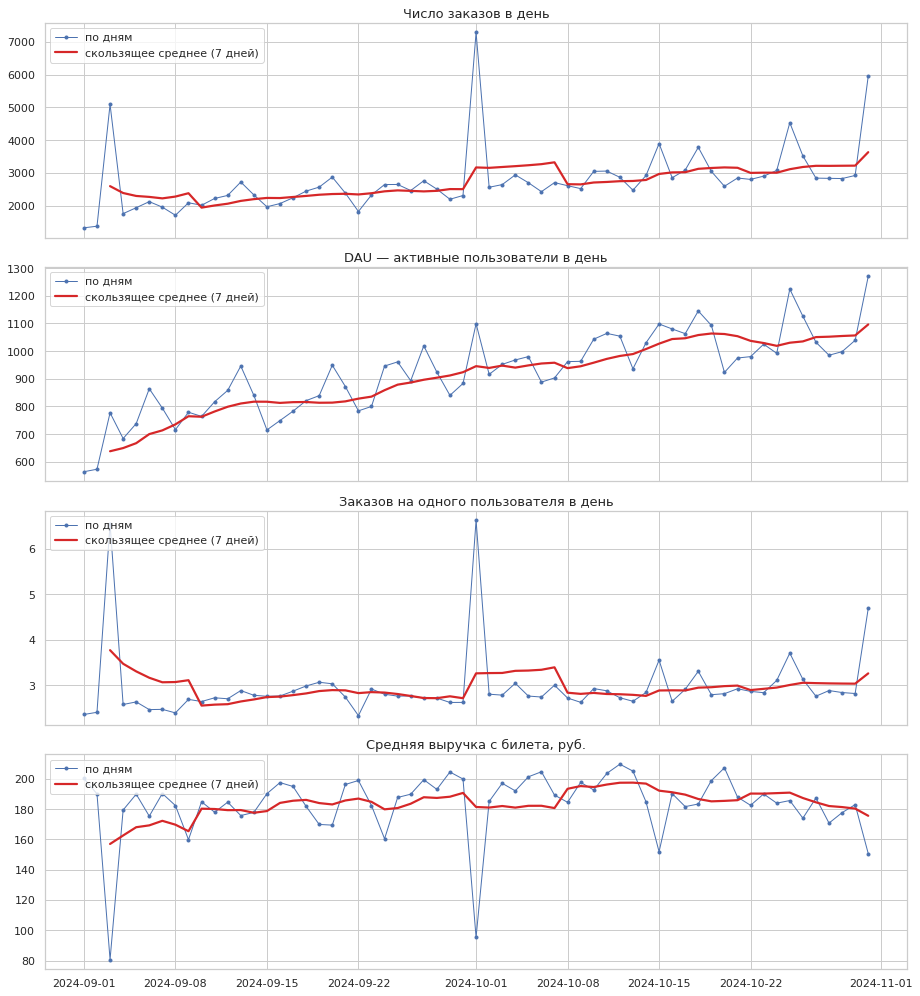

In [28]:
metrics = {'orders': 'Число заказов в день',
           'dau': 'DAU — активные пользователи в день',
           'orders_per_user': 'Заказов на одного пользователя в день',
           'avg_ticket_price': 'Средняя выручка с билета, руб.'}

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)
for ax, (col, title) in zip(axes, metrics.items()):
    ax.plot(daily['created_dt_msk'], daily[col], marker='o', ms=3, lw=1, label='по дням')
    ax.plot(daily['created_dt_msk'], daily[col].rolling(7, min_periods=3).mean(),
            lw=2.2, color='tab:red', label='скользящее среднее (7 дней)')
    ax.set_title(title)
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Недельная цикличность

Метрики усредняются по дням недели (выходные выделены цветом), затем сравниваются будни и выходные.

,orders,dau,orders_per_user,avg_ticket_price
Пн,"2,388.33",853.00,2.78,184.67
Вт,"3,493.22",934.11,3.72,156.93
Ср,"2,539.33",922.89,2.75,185.82
Чт,"3,012.89",960.89,3.06,182.18
Пт,"3,101.38","1,022.38",3.00,185.52
Сб,"2,666.00",960.38,2.76,192.61
Вс,"2,152.78",822.00,2.60,197.78


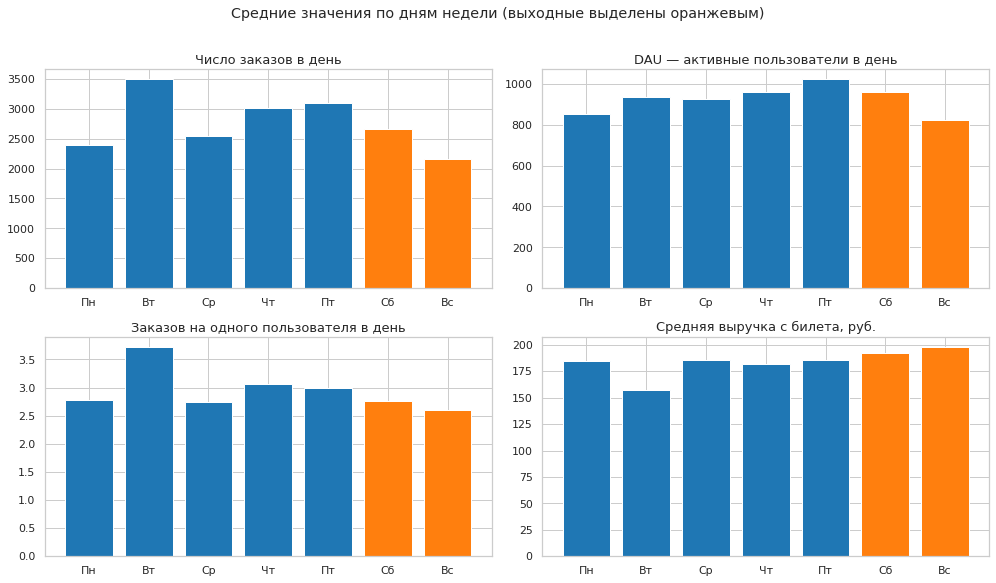

In [29]:
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
daily['weekday'] = daily['created_dt_msk'].dt.dayofweek
daily['day_type'] = np.where(daily['weekday'] >= 5, 'выходные', 'будни')

by_weekday = daily.groupby('weekday')[list(metrics)].mean()
by_weekday.index = [weekday_names[i] for i in by_weekday.index]
display(by_weekday.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (col, title) in zip(axes.ravel(), metrics.items()):
    colors = ['tab:orange' if d in ('Сб', 'Вс') else 'tab:blue' for d in by_weekday.index]
    ax.bar(by_weekday.index, by_weekday[col], color=colors)
    ax.set_title(title)
plt.suptitle('Средние значения по дням недели (выходные выделены оранжевым)', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
by_type = daily.groupby('day_type')[list(metrics)].mean().T
by_type['выходные к будням, %'] = (by_type['выходные'] / by_type['будни'] - 1) * 100
by_type.index = [metrics[i] for i in by_type.index]
display(by_type.round(2))

day_type,будни,выходные,"выходные к будням, %"
Число заказов в день,"2,902.61","2,394.29",-17.51
DAU — активные пользователи в день,936.75,887.12,-5.30
Заказов на одного пользователя в день,3.06,2.68,-12.67
"Средняя выручка с билета, руб.",178.88,195.35,9.21


### Промежуточный вывод по разделу 3.2

Осенняя активность заметно колеблется от дня к дню, при этом общий фон остаётся высоким и в октябре число заказов выше, чем в сентябре. Одновременно меняются DAU, число заказов на пользователя и средняя выручка с билета, что указывает на выраженную дневную и недельную вариативность спроса.

В недельном разрезе максимальное среднее число заказов приходится на вторник — 3 493 заказа в день, а максимальный средний DAU — на пятницу — 1 022 пользователя. Минимальные значения по этим двум показателям наблюдаются в воскресенье: 2 153 заказа и 822 активных пользователя в среднем.

Выходные характеризуются меньшей активностью, чем будни: заказов в среднем на 17,5% меньше, DAU — на 5,3% меньше, а заказов на одного активного пользователя — на 12,7% меньше. При этом средняя выручка с билета, наоборот, выше на выходных на 9,2%: 195,35 руб. против 178,88 руб.

Следовательно, недельная цикличность выражена не только в количестве заказов, но и в структуре поведения: в будни пользователей и заказов больше, а в выходные заказов меньше, но средняя стоимость одного билета выше. Это важно учитывать при планировании промоакций и интерпретации дневных колебаний.

## 3.3. Популярные события и партнёры

Здесь используем весь предобработанный период (лето + осень), чтобы получить устойчивую картину по регионам и партнёрам. При необходимости замените `df` на `autumn`, чтобы посмотреть только осень.

### 3.3.1. Регионы

Для каждого региона считаются число уникальных мероприятий и заказов и их доли от общего числа, а также накопленная доля топ-N регионов по заказам. Всего в данных 81 регион.

Регионов: 81


,events,orders,events_share_%,orders_share_%
region_name,,,,
Каменевский регион,5935,89662,26.62,31.20
Североярская область,3798,43724,17.04,15.22
Широковская область,1225,16099,5.49,5.60
Светополянский округ,1068,7486,4.79,2.61
Речиновская область,701,6265,3.14,2.18
Травяная область,683,5036,3.06,1.75
Горицветская область,551,5152,2.47,1.79
Серебринская область,541,5586,2.43,1.94
Яблоневская область,534,6120,2.40,2.13


Суммарная доля топ-N регионов по заказам, %:
{1: 31.2, 3: 52.0, 5: 60.5, 10: 71.8}


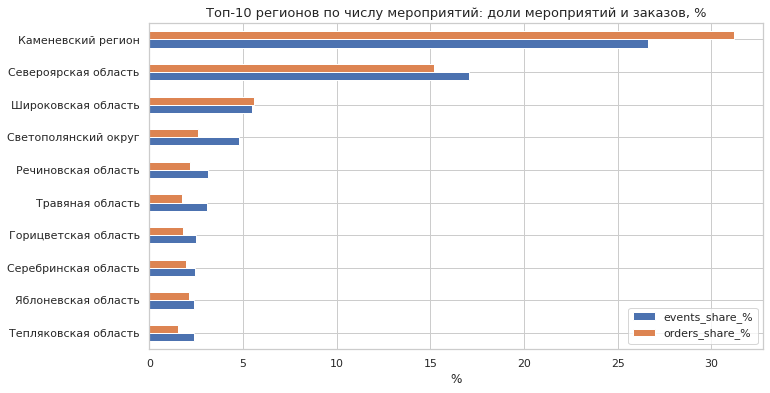

In [31]:
total_events = df['event_id'].nunique()
total_orders = df['order_id'].nunique()

regions = (df.groupby('region_name')
             .agg(events=('event_id', 'nunique'), orders=('order_id', 'nunique'))
             .sort_values('events', ascending=False))
regions['events_share_%'] = regions['events'] / total_events * 100
regions['orders_share_%'] = regions['orders'] / total_orders * 100

print(f'Регионов: {len(regions)}')
display(regions.head(10).round(2))

print('Суммарная доля топ-N регионов по заказам, %:')
cum = regions['orders_share_%'].sort_values(ascending=False).cumsum()
print({n: round(float(cum.iloc[n - 1]), 1) for n in (1, 3, 5, 10)})

top_reg = regions.head(10)[['events_share_%', 'orders_share_%']].iloc[::-1]
top_reg.plot(kind='barh', figsize=(11, 6))
plt.title('Топ-10 регионов по числу мероприятий: доли мероприятий и заказов, %')
plt.xlabel('%')
plt.ylabel('')
plt.show()

### 3.3.2. Билетные партнёры

Для каждого билетного партнёра считаются число мероприятий, заказов и выручка в рублях, а также их доли; отдельно оценивается концентрация выручки у топ-N партнёров. Всего в данных 36 партнёров.

Партнёров: 36


,events,orders,revenue_rub,events_share_%,orders_share_%,revenue_share_%
service_name,,,,,,
Билеты без проблем,4210,62631,"24,322,474.22",18.88,21.80,16.30
Мой билет,1300,34439,"22,042,027.60",5.83,11.98,14.77
Облачко,2335,26402,"18,588,613.86",10.47,9.19,12.45
Лови билет!,4859,40764,"16,673,895.20",21.80,14.19,11.17
Весь в билетах,855,16424,"16,532,346.46",3.84,5.72,11.08
Билеты в руки,3517,40186,"13,194,158.35",15.78,13.98,8.84
Край билетов,252,6109,"6,405,689.22",1.13,2.13,4.29
Прачечная,1026,10222,"4,746,810.52",4.60,3.56,3.18
Дом культуры,272,4412,"4,358,655.99",1.22,1.54,2.92


Суммарная доля топ-N партнёров по выручке, %: {1: 16.3, 3: 43.5, 5: 65.8, 10: 87.6}


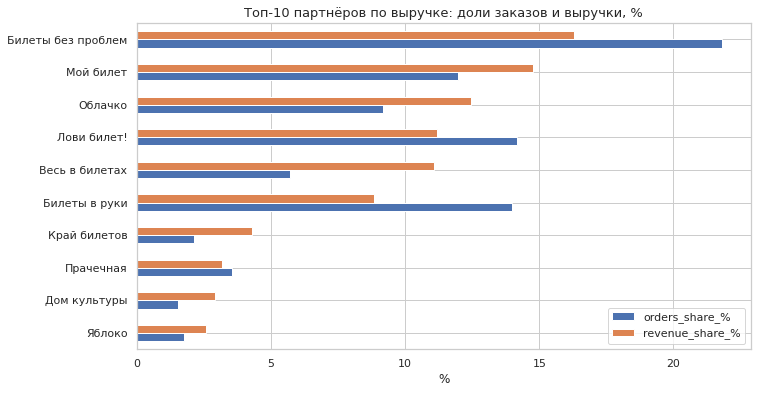

In [32]:
total_revenue = df['revenue_rub'].sum()

partners = (df.groupby('service_name')
              .agg(events=('event_id', 'nunique'),
                   orders=('order_id', 'nunique'),
                   revenue_rub=('revenue_rub', 'sum'))
              .sort_values('revenue_rub', ascending=False))
partners['events_share_%'] = partners['events'] / total_events * 100
partners['orders_share_%'] = partners['orders'] / total_orders * 100
partners['revenue_share_%'] = partners['revenue_rub'] / total_revenue * 100

print(f'Партнёров: {len(partners)}')
display(partners.head(10).round(2))

cum = partners['revenue_share_%'].cumsum()
print('Суммарная доля топ-N партнёров по выручке, %:', {n: round(float(cum.iloc[n - 1]), 1) for n in (1, 3, 5, 10) if n <= len(cum)})

top_par = partners.head(10)[['orders_share_%', 'revenue_share_%']].iloc[::-1]
top_par.plot(kind='barh', figsize=(11, 6))
plt.title('Топ-10 партнёров по выручке: доли заказов и выручки, %')
plt.xlabel('%')
plt.ylabel('')
plt.show()

### Промежуточный вывод по разделу 3.3

Распределение по регионам неравномерно. На Каменевский регион приходится 26,62% всех представленных мероприятий и 31,20% заказов, на Североярскую область — ещё 17,04% мероприятий и 15,22% заказов. Топ-3 региона обеспечивают 52,0% всех заказов, а топ-10 — 71,8%, поэтому значительная часть активности сосредоточена в ограниченном числе регионов.

По билетным партнёрам лидером по выручке является «Билеты без проблем» — 16,30% общей выручки, далее идут «Мой билет» — 14,77% и «Облачко» — 12,45%. При этом лидер по числу заказов и лидер по выручке не полностью совпадают: например, «Лови билет!» имеет 14,19% заказов, но 11,17% выручки, а «Весь в билетах» — только 5,72% заказов, но 11,08% выручки. Это показывает различия в среднем финансовом вкладе партнёров.

Концентрация выручки у партнёров высокая: на топ-5 приходится 65,8%, а на топ-10 — 87,6% общей выручки. Таким образом, и по регионам, и по партнёрам присутствует выраженная концентрация: несколько крупных участников формируют значительную долю результата, при этом сохраняется длинный хвост менее крупных регионов и партнёров.

---
# Шаг 4. Статистический анализ данных

Проверяем две гипотезы о том, что пользователи мобильных устройств активнее пользователей стационарных. Используем **только осенние данные**, уровень значимости **α = 0,05**.

### 4.0. Подготовка выборок

Чтобы группы были независимыми, нужно, чтобы каждый пользователь попал только в одну из них. Проверим, есть ли пользователи, которые заказывали с обоих типов устройств.

In [33]:
alpha = 0.05

devices_per_user = autumn.groupby('user_id')['device_type_canonical'].nunique()
both = devices_per_user[devices_per_user > 1].index
print(f'Пользователей осенью: {len(devices_per_user):,}')
print(f'Пользуются обоими типами устройств: {len(both):,} ({len(both) / len(devices_per_user):.2%})')

# Для независимости выборок исключаем пользователей, которые заказывали и с mobile, и с desktop
autumn_clean = autumn[~autumn['user_id'].isin(both)]
print(f'Осталось заказов: {len(autumn_clean):,} из {len(autumn):,}')

Пользователей осенью: 15,803
Пользуются обоими типами устройств: 3,249 (20.56%)
Осталось заказов: 34,428 из 168,418


Из 15 803 осенних пользователей 3 249 (20,56%) пользовались обоими типами устройств — они исключены, чтобы группы были независимыми. Это заметная часть данных: остаётся 34 428 заказов из 168 418, потому что исключённые пользователи делали в среднем около 41 заказа против примерно 2,7 у оставшихся. Поэтому выводы ниже относятся к пользователям, которые заказывали билеты только с одного типа устройств.

Для проверки гипотез определены две вспомогательные функции: `describe_groups` показывает описательные статистики и гистограммы двух групп (до 99-го процентиля), а `run_tests` считает односторонние t-тест Уэлча и тест Манна–Уитни.

In [34]:
def describe_groups(mobile, desktop, title):
    """Описательная статистика и распределения двух выборок."""
    stats_df = pd.DataFrame({'mobile': mobile.describe(), 'desktop': desktop.describe()})
    stats_df.loc['skew'] = [mobile.skew(), desktop.skew()]
    display(stats_df.round(3))

    upper = pd.concat([mobile, desktop]).quantile(0.99)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, data, name in zip(axes, [mobile, desktop], ['mobile', 'desktop']):
        sns.histplot(data[data <= upper], bins=40, ax=ax)
        ax.set_title(f'{title}: {name} (до 99-го перцентиля)')
    plt.tight_layout()
    plt.show()


def run_tests(mobile, desktop, alpha=0.05):
    """H0: среднее mobile <= среднее desktop; H1: среднее mobile > среднее desktop."""
    t_stat, t_p = st.ttest_ind(mobile, desktop, equal_var=False, alternative='greater')
    u_stat, u_p = st.mannwhitneyu(mobile, desktop, alternative='greater')
    print(f'Welch t-test:    t = {t_stat:8.3f}, p-value = {t_p:.4g} -> ' +
          ('H0 отвергаем' if t_p < alpha else 'H0 не отвергаем'))
    print(f'Mann–Whitney U:  U = {u_stat:,.0f}, p-value = {u_p:.4g} -> ' +
          ('H0 отвергаем' if u_p < alpha else 'H0 не отвергаем'))

### 4.1. Гипотеза 1: среднее число заказов на пользователя выше у пользователей мобильных устройств

- **H₀:** среднее число заказов на одного пользователя мобильных устройств **не выше**, чем у пользователей стационарных (μ_mobile ≤ μ_desktop).
- **H₁:** среднее число заказов на одного пользователя мобильных устройств **выше** (μ_mobile > μ_desktop) — односторонняя гипотеза.

**Выбор теста.** Сравниваем средние двух независимых выборок (пользователи не пересекаются), выборки большие, поэтому по ЦПТ подходит **t-тест Уэлча** (не предполагает равенства дисперсий). Но число заказов на пользователя — дискретная, сильно скошенная величина, поэтому для проверки устойчивости результата дополнительно используем **тест Манна–Уитни**.

Пользователей: mobile = 10,935, desktop = 1,619


,mobile,desktop
count,"10,935.00","1,619.00"
mean,2.86,1.97
std,4.10,3.06
min,1.00,1.00
25%,1.00,1.00
50%,2.00,1.00
75%,3.00,2.00
max,123.00,56.00
skew,7.59,9.88


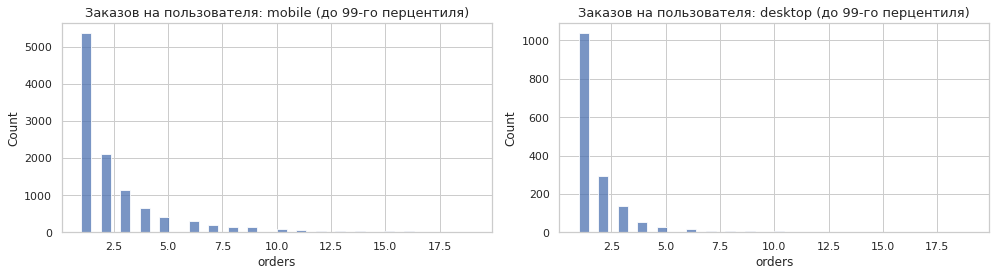

Welch t-test:    t =   10.359, p-value = 5.794e-25 -> H0 отвергаем
Mann–Whitney U:  U = 10,493,613, p-value = 4.784e-39 -> H0 отвергаем


In [35]:
user_orders = (autumn_clean.groupby(['user_id', 'device_type_canonical'])['order_id']
                           .nunique().reset_index(name='orders'))

mobile_orders = user_orders.loc[user_orders['device_type_canonical'] == 'mobile', 'orders']
desktop_orders = user_orders.loc[user_orders['device_type_canonical'] == 'desktop', 'orders']
print(f'Пользователей: mobile = {len(mobile_orders):,}, desktop = {len(desktop_orders):,}')

describe_groups(mobile_orders, desktop_orders, 'Заказов на пользователя')
run_tests(mobile_orders, desktop_orders, alpha)

**Вывод по гипотезе 1:** оба теста отвергают H₀ (p-value = 5,8·10⁻²⁵ у t-теста Уэлча и 4,8·10⁻³⁹ у теста Манна–Уитни при α = 0,05). Пользователи мобильных устройств в среднем делают 2,86 заказа против 1,97 у пользователей стационарных — на 0,89 заказа (около 45%) больше. Распределения сильно скошены вправо (медианы — 2 и 1 заказ, максимумы — 123 и 56), поэтому важно, что результат подтверждён непараметрическим тестом, который не зависит от экстремальных значений. Разница заметна и на практике, но относится только к тем, кто осенью заказывал билеты с одного типа устройств.

### 4.2. Гипотеза 2: среднее время между заказами выше у пользователей мобильных приложений

- **H₀:** среднее время между заказами пользователей мобильных устройств **не выше**, чем у пользователей стационарных (μ_mobile ≤ μ_desktop).
- **H₁:** среднее время между заказами пользователей мобильных устройств **выше** (μ_mobile > μ_desktop).

**Подготовка данных.** Показатель `days_since_prev` считается для каждого заказа, а заказы одного пользователя связаны между собой. Чтобы не нарушать независимость наблюдений, агрегируем до уровня пользователя — берём **среднее время между заказами для каждого пользователя** (первые покупки без значения не учитываются). Тест — тот же (Уэлч + Манн–Уитни), по тем же причинам.

Пользователей с повторными заказами: mobile = 7,052, desktop = 894


,mobile,desktop
count,"7,052.00",894.00
mean,25.25,31.36
std,30.21,36.56
min,0.00,0.00
25%,2.87,0.00
50%,14.00,16.00
75%,36.00,53.00
max,148.00,146.00
skew,1.60,1.11


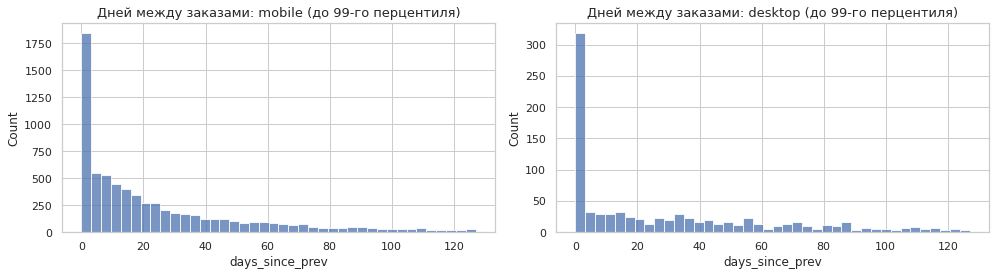

Welch t-test:    t =   -4.787, p-value = 1 -> H0 не отвергаем
Mann–Whitney U:  U = 3,099,864, p-value = 0.7921 -> H0 не отвергаем


In [36]:
user_gap = (autumn_clean.dropna(subset=['days_since_prev'])
                        .groupby(['user_id', 'device_type_canonical'])['days_since_prev']
                        .mean().reset_index())

mobile_gap = user_gap.loc[user_gap['device_type_canonical'] == 'mobile', 'days_since_prev']
desktop_gap = user_gap.loc[user_gap['device_type_canonical'] == 'desktop', 'days_since_prev']
print(f'Пользователей с повторными заказами: mobile = {len(mobile_gap):,}, desktop = {len(desktop_gap):,}')

describe_groups(mobile_gap, desktop_gap, 'Дней между заказами')
run_tests(mobile_gap, desktop_gap, alpha)

**Вывод по гипотезе 2:** оба теста не позволяют отвергнуть H₀ (p-value = 1,00 у t-теста Уэлча и 0,7921 у теста Манна–Уитни при α = 0,05). Среднее время между заказами у пользователей мобильных устройств не больше, а меньше: 25,25 дня против 31,36 у стационарных (примерно на 6 дней, медианы — 14 и 16 дней). Подтвердить, что мобильные пользователи возвращаются реже, нельзя. Обратное направление (у mobile время между заказами короче) в этой односторонней проверке не тестировалось.

### Промежуточный вывод по шагу 4

Статистический анализ проведён только на осенних данных и после исключения **3 249 пользователей (20,56%)**, которые использовали оба типа устройств, чтобы сохранить независимость групп.

- Гипотеза 1 о том, что среднее число заказов на пользователя выше у mobile, **подтвердилась по результатам обоих тестов**: средние **2,86 против 1,97**, разница **0,89 заказа**, p-values < 0,001.
- Гипотеза 2 о том, что среднее время между заказами выше у mobile, **не подтвердилась**: **25,25 против 31,36 дня**, при одностороннем тестировании p = 1,00 (Welch) и p = 0,7921 (Mann–Whitney).
- Интерпретация ограничена осенним периодом и выборкой пользователей, не смешивающих устройства. Результаты показывают статистическую связь в данной выборке, но сами по себе не доказывают причинный эффект типа устройства.

---
# Шаг 5. Общий вывод и рекомендации


## Данные

В исследовании использованы данные о заказах на Яндекс Афише за период **1 июня — 31 октября 2024 года** по мобильным и стационарным устройствам; фильмы исключены из анализа. Исходно было **290 849 заказов**, после объединения, очистки, удаления некорректных значений, неявных дубликатов и выбросов осталось **287 362 заказа (98,8%)**. Выручка в тенге приведена к рублям по курсу на дату заказа, а для контроля экстремальных значений 99-й процентиль рассчитывался отдельно по валютам.

## Основные результаты

- **Спрос и сезонность:** количество заказов устойчиво растёт от июня к октябрю: **34,1 тыс. → 99,2 тыс. заказов**. Особенно сильный рост наблюдается в сентябре (**+55,5% к августу**) и октябре (**+43,2% к сентябрю**). Осенью увеличивается доля спорта (**+8,67 п.п.**) и театра (**+5,24 п.п.**), а доля концертов снижается (**−5,43 п.п.**).

- **Средний чек:** средняя выручка с одного билета снизилась с **209,6 до 178,4 руб. (−14,9%)**. Основной вклад дал **эффект цены внутри типов мероприятий (−22,9 руб.)**, а изменение структуры спроса добавило ещё **−8,3 руб.** Значит, падение средней цены связано преимущественно с изменением цен внутри категорий, а не только с изменением структуры спроса.

- **Активность пользователей:** осенью активность высока, но заметно зависит от дня недели. Во вторник наблюдается максимальное среднее число заказов (**3 493 в день**), а в пятницу — максимальный средний DAU (**1 022**). В выходные заказов в среднем на **17,5% меньше**, DAU на **5,3% меньше**, но средняя выручка с билета на **9,2% выше**.

- **Регионы и партнёры:** на три крупнейших региона приходится **52,0% заказов**, на десять — **71,8%**. По выручке топ-5 билетных партнёров формируют **65,8%**, а топ-10 — **87,6%**. При этом доли заказов и выручки партнёров различаются, что указывает на разный средний финансовый вклад.

- **Прочее интересное:** мобильный канал доминирует на протяжении всего периода и практически не меняет долю: **80,62% летом и 79,64% осенью**. Это означает, что осенний рост спроса не связан с резким переходом аудитории на мобильные устройства.

## Проверка гипотез

- **Заказов на пользователя у mobile больше:** да, в данной выборке. Средние значения **2,86 против 1,97**, p = **5,794×10⁻²⁵** по Welch t-test и p = **4,784×10⁻³⁹** по Манна–Уитни.

- **Время между заказами у mobile больше:** нет статистических оснований подтвердить такую гипотезу. Средние значения **25,25 против 31,36 дня**; p = **1,00** по Welch t-test и p = **0,7921** по Манна–Уитни.

## Рекомендации

1. **Учитывать различия по устройствам в продуктовых и маркетинговых сценариях.** Мобильная группа в осенней выборке показывает существенно большее среднее число заказов на пользователя, поэтому имеет смысл отдельно анализировать мобильный путь пользователя, повторные покупки и персонализацию предложений.

2. **Отдельно исследовать причины падения цены билета.** Поскольку около трёх четвертей общего снижения средней цены приходится на эффект цены внутри типов мероприятий, полезно разложить изменение по категориям, регионам и партнёрам и проверить, связано ли оно с изменением ассортимента, скидками или ценовой политикой.

3. **Учитывать концентрацию при работе с регионами и партнёрами.** Значительная доля заказов и выручки сосредоточена у ограниченного числа регионов и билетных операторов, поэтому при планировании роста стоит одновременно развивать крупных партнёров и контролировать зависимость от них.

